In [3]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast

In [8]:
df_chat = pd.read_csv(
    "ecommerce_chatbot_QA_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df_chat.shape)
df_chat.head()


(55549, 10)


,"{""messages"": [{""role"": ""user""","""content"": ""I got to add an item to the cart""}","{""role"": ""assistant""","""content"": ""I'll get right on it! I'm here to assist you in adding an item to your cart. Here's a step-by-step guide to help you out:\n\n1. Browse through our {{Product Catalog}} to find the item you want to add to your cart.\n2. Once you've found the item","click on the \""{{Add to Cart}}\"" button or select the desired quantity from the available options.\n3. You'll be redirected to your cart page",where you can review your selected items.\n4. If you want to continue shopping,"simply click on the \""{{Continue Shopping}}\"" button",and you'll be taken back to the catalog.\n5. If you're ready to proceed,"click on the \""{{Checkout}}\"" button to finalize your purchase.\n\nIf you encounter any difficulties during this process","please don't hesitate to let me know. I'm here to help you with any questions or concerns you may have. Happy shopping!""}]}"
0,"{""messages"": [{""role"": ""user""","""content"": ""wanna add fucking products to the...","{""role"": ""assistant""","""content"": ""I sincerely apologize if you've e...",follow these simple steps:\n\n1. Browse throu...,"click on the \""{{Add to Basket}}\"" button or ...",usually indicated by a mini shopping cart ico...,"click on the \""{{Checkout}}\"" or \""{{Proceed ...",don't hesitate to reach out. I'm here to help...,NaN
1,"{""messages"": [{""role"": ""user""","""content"": ""i have to add products to the bas...","{""role"": ""assistant""","""content"": ""You bet! I'm here to assist you i...","click on the \""Add to Basket\"" button or a si...",you can easily update it by adjusting the qua...,click on the basket or cart icon,usually located at the top right corner of th...,"click on the \""Checkout\"" or \""Proceed to Che...","feel free to reach out. Happy shopping!""}]}"
2,"{""messages"": [{""role"": ""user""","""content"": ""di like to add products to the ca...","{""role"": ""assistant""","""content"": ""Indeed! I'm here to assist you in...","click on the \""Add to Cart\"" button.\n3. If y...",simply repeat the process for other items.\n4...,click on the shopping cart icon at the top ri...,"click on the \""Checkout\"" button to finalize ...","feel free to ask. Happy shopping!""}]}",NaN
3,"{""messages"": [{""role"": ""user""","""content"": ""I need to add an item to the cart","where do I do it?""}","{""role"": ""assistant""","""content"": ""I'll take care of it! I'm here to...",simply follow these steps:\n\n1. Browse throu...,"click on the \""Add to Cart\"" button or icon n...",you can repeat the process for additional ite...,proceed to the checkout page to complete your...,feel free to let me know. I'm here to make yo...
4,"{""messages"": [{""role"": ""user""","""content"": ""help me add products to the basket""}","{""role"": ""assistant""","""content"": ""I'm happy to help! I'm here to gu...",you can proceed to the checkout by clicking o...,"feel free to ask. Happy shopping!""}]}",NaN,NaN,NaN,NaN


In [9]:
print(df_chat.columns.tolist())

['{"messages": [{"role": "user"', ' "content": "I got to add an item to the cart"}', ' {"role": "assistant"', ' "content": "I\'ll get right on it! I\'m here to assist you in adding an item to your cart. Here\'s a step-by-step guide to help you out:\\n\\n1. Browse through our {{Product Catalog}} to find the item you want to add to your cart.\\n2. Once you\'ve found the item', ' click on the \\"{{Add to Cart}}\\" button or select the desired quantity from the available options.\\n3. You\'ll be redirected to your cart page', ' where you can review your selected items.\\n4. If you want to continue shopping', ' simply click on the \\"{{Continue Shopping}}\\" button', " and you'll be taken back to the catalog.\\n5. If you're ready to proceed", ' click on the \\"{{Checkout}}\\" button to finalize your purchase.\\n\\nIf you encounter any difficulties during this process', ' please don\'t hesitate to let me know. I\'m here to help you with any questions or concerns you may have. Happy shopping!

In [11]:
df_chat.info()

<class 'pandas.DataFrame'>
RangeIndex: 55549 entries, 0 to 55548
Data columns (total 10 columns):
 #   Column                                                                                                                                                                                                                                                             Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                                             --------------  -----
 0   {"messages": [{"role": "user"                                                                                                                                                                                                                                      55549 non-null  str  
 1    "content": "I got to add an item to th

In [13]:
import pandas as pd
import json

# Read as raw text lines
with open("ecommerce_chatbot_QA_dataset.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

Total lines: 69037


In [14]:
data = []

for line in lines:
    try:
        data.append(json.loads(line))
    except:
        continue

print("Parsed records:", len(data))

Parsed records: 69037


In [15]:
df_chat = pd.DataFrame(data)

print(df_chat.shape)
df_chat.head()

(69037, 1)


,messages
0,"[{'role': 'user', 'content': 'I got to add an ..."
1,"[{'role': 'user', 'content': 'wanna add fuckin..."
2,"[{'role': 'user', 'content': 'i have to add pr..."
3,"[{'role': 'user', 'content': 'di like to add p..."
4,"[{'role': 'user', 'content': 'I need to add an..."


In [16]:
def extract_prompt_response(messages):
    try:
        user_prompt = None
        assistant_response = None
        
        for msg in messages:
            if msg["role"] == "user" and user_prompt is None:
                user_prompt = msg["content"]
            if msg["role"] == "assistant" and assistant_response is None:
                assistant_response = msg["content"]
        
        return pd.Series([user_prompt, assistant_response])
    
    except:
        return pd.Series([None, None])

df_chat[["prompt", "ai_response"]] = df_chat["messages"].apply(extract_prompt_response)

df_chat.head()

,messages,prompt,ai_response
0,"[{'role': 'user', 'content': 'I got to add an ...",I got to add an item to the cart,I'll get right on it! I'm here to assist you i...
1,"[{'role': 'user', 'content': 'wanna add fuckin...",wanna add fucking products to the basket can h...,I sincerely apologize if you've encountered an...
2,"[{'role': 'user', 'content': 'i have to add pr...",i have to add products to the basket i ned help,You bet! I'm here to assist you in adding prod...
3,"[{'role': 'user', 'content': 'di like to add p...",di like to add products to the cart could i ge...,Indeed! I'm here to assist you in adding produ...
4,"[{'role': 'user', 'content': 'I need to add an...","I need to add an item to the cart , where do I...",I'll take care of it! I'm here to help you wit...


In [17]:
df_chat = df_chat.dropna(subset=["prompt", "ai_response"]).reset_index(drop=True)

print(df_chat.shape)

(69037, 3)


In [18]:
import numpy as np

df_eval_chat = pd.DataFrame({
    "dataset": "ecommerce_chatbot_qa",
    "record_id": df_chat.index,
    "prompt": df_chat["prompt"],
    "ai_response": df_chat["ai_response"],
    
    # ✅ Scoring fields (robustness-focused)
    "relevance_score": np.nan,
    "intent_reflection_score": np.nan,
    "robustness_to_noise_score": np.nan,
    "task_guidance_score": np.nan,
    "clarity_score": np.nan,
    "business_usefulness_score": np.nan,
    
    # ✅ Behaviour + errors
    "prompt_type": "",
    "error_types": "",
    "edge_case_flag": False,
    
    # ✅ Evaluation comments
    "decision_summary": "",
    "score_justification": "",
    "improvement_recommendation": ""
})

df_eval_chat.head()

,dataset,record_id,prompt,ai_response,relevance_score,intent_reflection_score,robustness_to_noise_score,task_guidance_score,clarity_score,business_usefulness_score,prompt_type,error_types,edge_case_flag,decision_summary,score_justification,improvement_recommendation
0,ecommerce_chatbot_qa,0,I got to add an item to the cart,I'll get right on it! I'm here to assist you i...,NaN,NaN,NaN,NaN,NaN,NaN,,,False,,,
1,ecommerce_chatbot_qa,1,wanna add fucking products to the basket can h...,I sincerely apologize if you've encountered an...,NaN,NaN,NaN,NaN,NaN,NaN,,,False,,,
2,ecommerce_chatbot_qa,2,i have to add products to the basket i ned help,You bet! I'm here to assist you in adding prod...,NaN,NaN,NaN,NaN,NaN,NaN,,,False,,,
3,ecommerce_chatbot_qa,3,di like to add products to the cart could i ge...,Indeed! I'm here to assist you in adding produ...,NaN,NaN,NaN,NaN,NaN,NaN,,,False,,,
4,ecommerce_chatbot_qa,4,"I need to add an item to the cart , where do I...",I'll take care of it! I'm here to help you wit...,NaN,NaN,NaN,NaN,NaN,NaN,,,False,,,


In [19]:
def tag_prompt_type(prompt):
    p = str(prompt).lower()

    if any(w in p for w in ["fuck", "damn", "angry", "unacceptable", "hate"]):
        return "rude_emotional"
    
    elif len(p.split()) < 4:
        return "incomplete"
    
    elif " and " in p or "," in p:
        return "multi_intent"
    
    elif any(char.isdigit() for char in p):
        return "ambiguous"
    
    elif sum(1 for word in p.split() if len(word) <= 2) > 3:
        return "typo_heavy"
    
    else:
        return "polite"

In [20]:
df_eval_chat["prompt_type"] = df_eval_chat["prompt"].apply(tag_prompt_type)

In [21]:
df_eval_chat["edge_case_flag"] = df_eval_chat["prompt_type"].isin([
    "rude_emotional",
    "incomplete",
    "ambiguous",
    "multi_intent",
    "typo_heavy"
])

In [22]:
df_eval_chat["prompt_type"].value_counts()

prompt_type
rude_emotional    21788
polite            19549
multi_intent      14986
typo_heavy        12181
incomplete          529
ambiguous             4
Name: count, dtype: int64

In [23]:
score_cols_chat = [
    "relevance_score",
    "intent_reflection_score",
    "robustness_to_noise_score",
    "task_guidance_score",
    "clarity_score",
    "business_usefulness_score"
]

In [24]:
def score_relevance(prompt, response):
    overlap = sum(word in str(response).lower() for word in str(prompt).lower().split())
    return 4 if overlap >= 2 else 3

def score_intent_reflection(prompt, response):
    return score_relevance(prompt, response)

def score_noise_robustness(prompt, response):
    if tag_prompt_type(prompt) != "polite":
        return 4 if len(str(response)) > 30 else 2
    return 4

def score_task_guidance(response):
    if any(word in str(response).lower() for word in ["step", "click", "go to", "select", "check"]):
        return 4
    return 3

def score_clarity(response):
    words = str(response).split()
    if len(words) < 20:
        return 2
    elif len(words) <= 120:
        return 4
    else:
        return 3

In [25]:
df_eval_chat["relevance_score"] = df_eval_chat.apply(
    lambda x: score_relevance(x["prompt"], x["ai_response"]), axis=1
)

df_eval_chat["intent_reflection_score"] = df_eval_chat.apply(
    lambda x: score_intent_reflection(x["prompt"], x["ai_response"]), axis=1
)

df_eval_chat["robustness_to_noise_score"] = df_eval_chat.apply(
    lambda x: score_noise_robustness(x["prompt"], x["ai_response"]), axis=1
)

df_eval_chat["task_guidance_score"] = df_eval_chat["ai_response"].apply(score_task_guidance)

df_eval_chat["clarity_score"] = df_eval_chat["ai_response"].apply(score_clarity)

df_eval_chat["business_usefulness_score"] = 3  # neutral baseline

In [26]:
df_eval_chat["overall_score"] = df_eval_chat[score_cols_chat].mean(axis=1)

In [27]:
def assign_chat_errors(prompt, response):
    errors = []
    r = str(response).lower()

    if len(r.split()) < 30:
        errors.append("missing_key_step_or_omission")

    if any(p in r for p in ["i'm here", "i can help", "let me help"]):
        errors.append("overly_generic_response")

    if len(r.split()) > 180:
        errors.append("too_verbose_or_inefficient")

    if tag_prompt_type(prompt) != "polite" and len(r.split()) < 40:
        errors.append("weak_prompt_handling")

    return "; ".join(errors)

df_eval_chat["error_types"] = df_eval_chat.apply(
    lambda x: assign_chat_errors(x["prompt"], x["ai_response"]), axis=1
)

In [28]:
df_eval_chat.head()

,dataset,record_id,prompt,ai_response,relevance_score,intent_reflection_score,robustness_to_noise_score,task_guidance_score,clarity_score,business_usefulness_score,prompt_type,error_types,edge_case_flag,decision_summary,score_justification,improvement_recommendation,overall_score
0,ecommerce_chatbot_qa,0,I got to add an item to the cart,I'll get right on it! I'm here to assist you i...,4,4,4,4,3,3,typo_heavy,overly_generic_response,True,,,,3.666667
1,ecommerce_chatbot_qa,1,wanna add fucking products to the basket can h...,I sincerely apologize if you've encountered an...,4,4,4,4,3,3,rude_emotional,overly_generic_response,True,,,,3.666667
2,ecommerce_chatbot_qa,2,i have to add products to the basket i ned help,You bet! I'm here to assist you in adding prod...,4,4,4,4,3,3,typo_heavy,overly_generic_response; too_verbose_or_ineffi...,True,,,,3.666667
3,ecommerce_chatbot_qa,3,di like to add products to the cart could i ge...,Indeed! I'm here to assist you in adding produ...,4,4,4,4,3,3,typo_heavy,overly_generic_response,True,,,,3.666667
4,ecommerce_chatbot_qa,4,"I need to add an item to the cart , where do I...",I'll take care of it! I'm here to help you wit...,4,4,4,4,3,3,multi_intent,overly_generic_response,True,,,,3.666667


In [29]:
score_cols_chat = [
    "relevance_score",
    "intent_reflection_score",
    "robustness_to_noise_score",
    "task_guidance_score",
    "clarity_score",
    "business_usefulness_score"
]

df_eval_chat["overall_score"] = df_eval_chat[score_cols_chat].mean(axis=1)

df_eval_chat[["prompt", "prompt_type", "overall_score"]].head()

,prompt,prompt_type,overall_score
0,I got to add an item to the cart,typo_heavy,3.666667
1,wanna add fucking products to the basket can h...,rude_emotional,3.666667
2,i have to add products to the basket i ned help,typo_heavy,3.666667
3,di like to add products to the cart could i ge...,typo_heavy,3.666667
4,"I need to add an item to the cart , where do I...",multi_intent,3.666667


In [30]:
prompt_type_scores = (
    df_eval_chat.groupby("prompt_type")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
)

print("Average Score by Prompt Type:")
print(prompt_type_scores)

Average Score by Prompt Type:
      prompt_type  overall_score
1      incomplete       3.231884
3          polite       3.592562
2    multi_intent       3.656824
0       ambiguous       3.666667
5      typo_heavy       3.667707
4  rude_emotional       3.675739


In [31]:
low_quality_pct_chat = (df_eval_chat["overall_score"] < 3).mean() * 100
print(f"Low-quality responses: {low_quality_pct_chat:.2f}%")

Low-quality responses: 0.00%


In [32]:
edge_case_fail_pct_chat = (
    df_eval_chat[df_eval_chat["edge_case_flag"] == True]["overall_score"]
    .lt(3)
    .mean() * 100
)

print(f"Edge-case failure rate: {edge_case_fail_pct_chat:.2f}%")

Edge-case failure rate: 0.00%


In [33]:
edge_vs_normal = (
    df_eval_chat.groupby("edge_case_flag")["overall_score"]
    .mean()
    .reset_index()
)

print(edge_vs_normal)

   edge_case_flag  overall_score
0           False       3.592562
1            True       3.663289


In [34]:
from collections import Counter

error_list_chat = []

for entry in df_eval_chat["error_types"].dropna():
    entry = str(entry).strip()
    if entry != "":
        error_list_chat.extend([err.strip() for err in entry.split(";") if err.strip() != ""])

error_counts_chat = pd.DataFrame(
    Counter(error_list_chat).items(),
    columns=["error_type", "count"]
).sort_values("count", ascending=False)

print(error_counts_chat)

                     error_type  count
0       overly_generic_response  30959
3  missing_key_step_or_omission  12502
1    too_verbose_or_inefficient   9519
2          weak_prompt_handling   8341


In [35]:
low_quality_by_prompt = (
    df_eval_chat.assign(low_quality=df_eval_chat["overall_score"] < 3)
    .groupby("prompt_type")["low_quality"]
    .mean()
    .reset_index()
    .sort_values("low_quality", ascending=False)
)

print(low_quality_by_prompt)

      prompt_type  low_quality
0       ambiguous          0.0
1      incomplete          0.0
2    multi_intent          0.0
3          polite          0.0
4  rude_emotional          0.0
5      typo_heavy          0.0


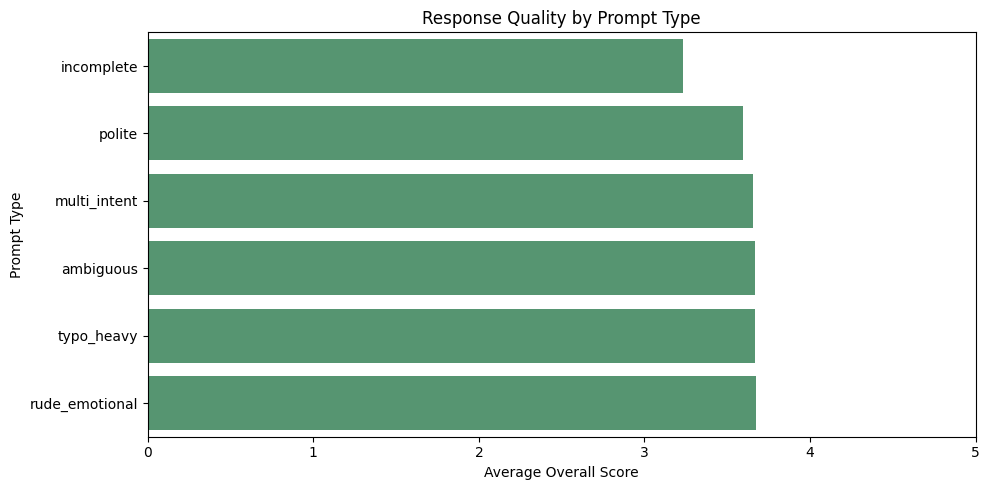

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(data=prompt_type_scores, x="overall_score", y="prompt_type", color="#4C9F70")
plt.title("Response Quality by Prompt Type")
plt.xlabel("Average Overall Score")
plt.ylabel("Prompt Type")
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig("chatbot_qa_response_quality_by_prompt_type.png", dpi=300, bbox_inches="tight")
plt.show()

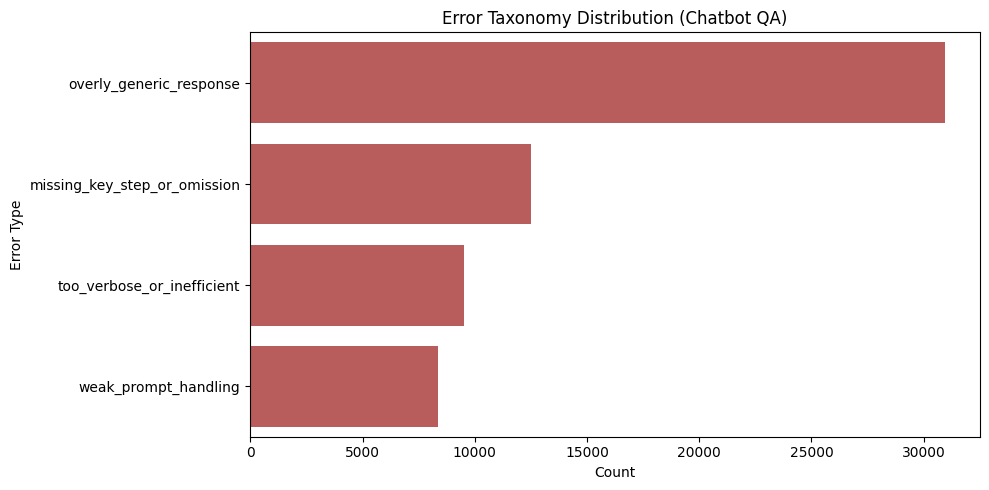

In [37]:
plt.figure(figsize=(10, 5))
sns.barplot(data=error_counts_chat, x="count", y="error_type", color="#C94C4C")
plt.title("Error Taxonomy Distribution (Chatbot QA)")
plt.xlabel("Count")
plt.ylabel("Error Type")
plt.tight_layout()
plt.savefig("chatbot_qa_error_taxonomy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

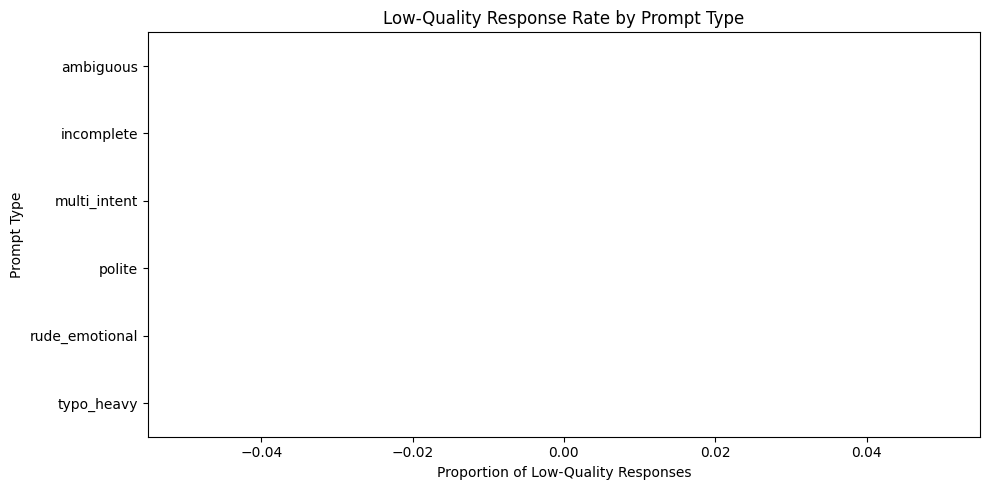

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=low_quality_by_prompt, x="low_quality", y="prompt_type", color="#E67E22")
plt.title("Low-Quality Response Rate by Prompt Type")
plt.xlabel("Proportion of Low-Quality Responses")
plt.ylabel("Prompt Type")
plt.tight_layout()
plt.savefig("chatbot_qa_low_quality_by_prompt_type.png", dpi=300, bbox_inches="tight")
plt.show()

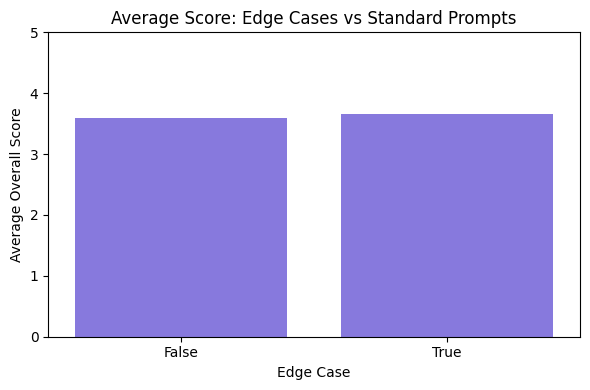

In [39]:
plt.figure(figsize=(6, 4))
sns.barplot(data=edge_vs_normal, x="edge_case_flag", y="overall_score", color="#7B68EE")
plt.title("Average Score: Edge Cases vs Standard Prompts")
plt.xlabel("Edge Case")
plt.ylabel("Average Overall Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("chatbot_qa_edge_vs_normal_scores.png", dpi=300, bbox_inches="tight")
plt.show()

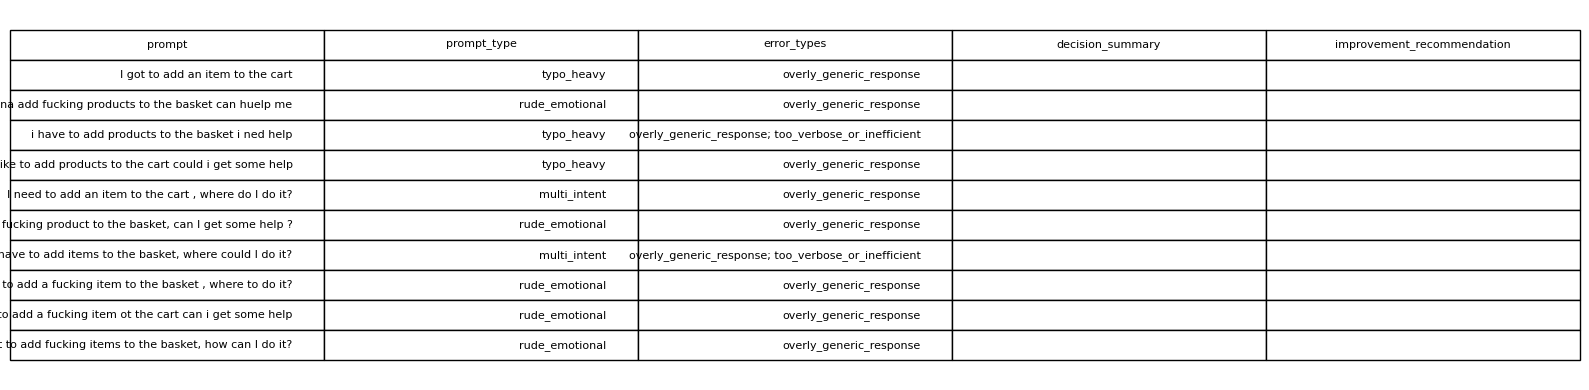

In [40]:
edge_cases_chat = df_eval_chat[df_eval_chat["edge_case_flag"] == True][[
    "prompt", "prompt_type", "error_types", "decision_summary", "improvement_recommendation"
]].head(10)

edge_cases_chat.to_csv("chatbot_qa_edge_case_examples.csv", index=False)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')
tbl = ax.table(
    cellText=edge_cases_chat.values,
    colLabels=edge_cases_chat.columns,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
plt.tight_layout()
plt.savefig("chatbot_qa_edge_case_examples_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
df_eval_chat.to_csv("chatbot_qa_scored_results.csv", index=False)